# Q4: Eco-Friendly Agents (Lower CO₂ and Water Use)

Four agents, one per type. Each is built twice: an **eco** version that treats CO₂ and water as part of its decision, and a **baseline** version that ignores them. Both versions run on identical simulated data, and the footprint of each is compared at the end.

**Assumptions (all values are simulated):** CO₂ is measured in grams and water in litres. Costs per action are illustrative, not measured. Every random process uses a fixed seed so results are reproducible.

| Agent | Type | Task | Eco mechanism |
|---|---|---|---|
| A | Simple reflex | Abnormal crowd movement | Low-power watching, full scan only on a trigger |
| B | Utility-based | Stressed patients | Utility = relief − footprint penalty |
| C | Goal-based | School van commute | Safe roads only, shortest planned route |
| D | Learning | Youth sports | Bandit reward = engagement − footprint penalty |

In [1]:
import heapq
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)

results = []


class EcoMeter:
    def __init__(self):
        self.co2 = 0.0
        self.water = 0.0

    def spend(self, co2=0.0, water=0.0):
        self.co2 += co2
        self.water += water


def log(agent, variant, meter, note):
    results.append({"agent": agent, "variant": variant, "co2_g": round(meter.co2, 2), "water_l": round(meter.water, 2), "note": note})

## Agent A: Reflex agent (abnormal crowd movement)

**PEAS:** the performance measure is the number of abnormal events caught with low energy use. The environment is a camera feed of a crowd. The actuator is an alert. The sensors are average crowd speed and direction spread.

**Rule:** if speed > 2.5 or direction spread > 1.2, raise an alert, otherwise do nothing. There is no memory or planning, only condition-action rules.

**Eco design:** the baseline runs a full high-power scan on every frame. The eco agent stays in low-power watch mode and only wakes the full pipeline when a rule fires.

In [2]:
class ReflexCrowdAgent:
    def __init__(self, eco, speed_limit=2.5, spread_limit=1.2):
        self.eco = eco
        self.speed_limit = speed_limit
        self.spread_limit = spread_limit
        self.meter = EcoMeter()
        self.alerts = 0

    def act(self, frame):
        abnormal = frame["speed"] > self.speed_limit or frame["spread"] > self.spread_limit
        if abnormal:
            self.meter.spend(40, 0.02)
            self.alerts += 1
            return "ALERT"
        if self.eco:
            self.meter.spend(2, 0.001)
            return "LOW_POWER_WATCH"
        self.meter.spend(40, 0.02)
        return "FULL_SCAN"


def make_crowd(n=200, p_abnormal=0.06):
    frames = []
    for _ in range(n):
        if random.random() < p_abnormal:
            frames.append({"speed": random.uniform(3, 6), "spread": random.uniform(1.5, 3)})
        else:
            frames.append({"speed": random.uniform(0.5, 2), "spread": random.uniform(0.2, 1)})
    return frames


crowd = make_crowd()
for eco in (False, True):
    agent = ReflexCrowdAgent(eco)
    for frame in crowd:
        agent.act(frame)
    log("A Reflex", "eco" if eco else "baseline", agent.meter, f"{agent.alerts} alerts")

print(pd.DataFrame(results))

      agent   variant   co2_g  water_l       note
0  A Reflex  baseline  8000.0     4.00  11 alerts
1  A Reflex       eco   818.0     0.41  11 alerts


## Agent B: Utility-based agent (stressed and tense patients)

**Percepts:** heart rate and breathing rate, converted to a stress score from 0 to 10. **Actions:** breathing guide, soft music, dim lights, warm shower, call nurse.

**Utility:** `U(action) = relief × stress/10 − w × (CO₂/100 + 0.1 × water)`

The agent picks the action with the highest utility. The eco agent uses `w = 1`. The baseline uses `w = 0`, so it only maximises comfort and ends up choosing the warm shower, which is water-heavy. The eco agent trades a little relief for a much lower footprint, and still escalates to the nurse when stress is high.

In [3]:
ACTIONS = {
    "breathing_guide": {"relief": 4, "co2": 5, "water": 0.0},
    "soft_music": {"relief": 5, "co2": 10, "water": 0.0},
    "dim_lights": {"relief": 3, "co2": 2, "water": 0.0},
    "warm_shower": {"relief": 9, "co2": 1200, "water": 40.0},
    "call_nurse": {"relief": 8, "co2": 60, "water": 0.5},
}


class UtilityPatientAgent:
    def __init__(self, eco_weight):
        self.w = eco_weight
        self.meter = EcoMeter()
        self.history = []

    def stress(self, heart_rate, breathing_rate):
        return float(np.clip(0.1 * (heart_rate - 60) + 0.25 * (breathing_rate - 12), 0, 10))

    def utility(self, name, stress):
        a = ACTIONS[name]
        return a["relief"] * stress / 10 - self.w * (a["co2"] / 100 + 0.1 * a["water"])

    def act(self, heart_rate, breathing_rate):
        s = self.stress(heart_rate, breathing_rate)
        best = max(ACTIONS, key=lambda n: self.utility(n, s))
        self.meter.spend(ACTIONS[best]["co2"], ACTIONS[best]["water"])
        self.history.append(best)
        return best


patients = [(random.uniform(60, 130), random.uniform(12, 30)) for _ in range(50)]
choices = {}
for name, w in (("baseline", 0.0), ("eco", 1.0)):
    agent = UtilityPatientAgent(w)
    for hr, br in patients:
        agent.act(hr, br)
    choices[name] = pd.Series(agent.history).value_counts().to_dict()
    log("B Utility", name, agent.meter, f"{choices[name]}")

print(choices)

{'baseline': {'warm_shower': 50}, 'eco': {'call_nurse': 45, 'soft_music': 5}}


## Agent C: Goal-based agent (secure school van network)

**Goal:** pick up every student and reach the school using only roads marked safe, with minimum distance.

**Method:** Dijkstra gives the shortest paths between stops, and the agent repeatedly drives to the nearest unvisited stop (planning toward the goal), then to the school. Eco cost is distance × 270 g CO₂/km and 0.3 L/km (an assumed upstream fuel-water cost).

**Baseline:** visits the stops in a fixed order on the shortest roads, ignoring safety. The result shows both footprint and unsafe kilometres.

In [4]:
ROADS = {
    ("Depot", "S1"): 2.0, ("Depot", "S2"): 4.0, ("S1", "S2"): 1.5, ("S1", "S3"): 3.5,
    ("S2", "S3"): 2.0, ("S2", "S4"): 3.0, ("S3", "S4"): 1.5, ("S3", "School"): 3.0,
    ("S4", "School"): 2.0,
}
UNSAFE = {("Depot", "S2"), ("S2", "S4"), ("S3", "School")}
STOPS = ["S1", "S2", "S3", "S4"]


def build_graph(safe_only):
    graph = {}
    for (a, b), km in ROADS.items():
        if safe_only and (a, b) in UNSAFE:
            continue
        graph.setdefault(a, {})[b] = km
        graph.setdefault(b, {})[a] = km
    return graph


def dijkstra(graph, start, goal):
    queue = [(0.0, start, [start])]
    seen = set()
    while queue:
        dist, node, path = heapq.heappop(queue)
        if node == goal:
            return dist, path
        if node in seen:
            continue
        seen.add(node)
        for nxt, km in graph.get(node, {}).items():
            heapq.heappush(queue, (dist + km, nxt, path + [nxt]))
    return float("inf"), []


class GoalVanAgent:
    def __init__(self, eco):
        self.eco = eco
        self.graph = build_graph(safe_only=eco)
        self.meter = EcoMeter()
        self.route = ["Depot"]
        self.km = 0.0

    def drive(self, target):
        dist, path = dijkstra(self.graph, self.route[-1], target)
        self.km += dist
        self.route += path[1:]
        self.meter.spend(270 * dist, 0.3 * dist)

    def run(self):
        pending = list(STOPS) if self.eco else ["S2", "S1", "S4", "S3"]
        while pending:
            if self.eco:
                target = min(pending, key=lambda s: dijkstra(self.graph, self.route[-1], s)[0])
            else:
                target = pending[0]
            pending.remove(target)
            self.drive(target)
        self.drive("School")

    def unsafe_km(self):
        total = 0.0
        for a, b in zip(self.route, self.route[1:]):
            if (a, b) in UNSAFE or (b, a) in UNSAFE:
                total += ROADS.get((a, b), ROADS.get((b, a)))
        return total


for eco in (False, True):
    van = GoalVanAgent(eco)
    van.run()
    log("C Goal", "eco" if eco else "baseline", van.meter, f"{van.km:.1f} km, {van.unsafe_km():.1f} km unsafe")
    print("eco" if eco else "baseline", " > ".join(van.route))

baseline Depot > S1 > S2 > S1 > S2 > S4 > S3 > School
eco Depot > S1 > S2 > S3 > S4 > School


## Agent D: Learning agent (encourage sports in young people)

**Task:** learn which activity to recommend to a young person: walking, cycling, football, swimming or gym.

**Method:** an ε-greedy bandit with a decaying ε. After each recommendation the agent observes engagement (noisy, between 0 and 1) and updates its value estimate with an incremental mean.

**Reward:** `engagement − λ × (CO₂/2000 + 0.02 × water)`. The eco agent uses `λ = 1`. The baseline uses `λ = 0`, so it learns that swimming is the most engaging activity even though it uses lots of water. The eco agent learns that football is a better overall choice.

In [5]:
SPORTS = {
    "walking": {"engage": 0.50, "co2": 0, "water": 0.0},
    "cycling": {"engage": 0.70, "co2": 0, "water": 0.0},
    "football": {"engage": 0.85, "co2": 0, "water": 2.0},
    "swimming": {"engage": 0.90, "co2": 300, "water": 15.0},
    "gym": {"engage": 0.60, "co2": 800, "water": 0.0},
}


class LearningSportsAgent:
    def __init__(self, eco_lambda, seed):
        self.lam = eco_lambda
        self.rng = np.random.default_rng(seed)
        self.q = {s: 0.0 for s in SPORTS}
        self.n = {s: 0 for s in SPORTS}
        self.meter = EcoMeter()

    def penalty(self, s):
        return SPORTS[s]["co2"] / 2000 + 0.02 * SPORTS[s]["water"]

    def choose(self, step):
        epsilon = max(0.05, 1.0 / (1 + 0.02 * step))
        if self.rng.random() < epsilon:
            return self.rng.choice(list(SPORTS))
        return max(self.q, key=self.q.get)

    def learn(self, rounds=1000):
        for step in range(rounds):
            s = self.choose(step)
            engage = float(np.clip(self.rng.normal(SPORTS[s]["engage"], 0.1), 0, 1))
            reward = engage - self.lam * self.penalty(s)
            self.n[s] += 1
            self.q[s] += (reward - self.q[s]) / self.n[s]
            self.meter.spend(SPORTS[s]["co2"], SPORTS[s]["water"])


learned = {}
for name, lam in (("baseline", 0.0), ("eco", 1.0)):
    agent = LearningSportsAgent(lam, seed=11)
    agent.learn()
    learned[name] = max(agent.q, key=agent.q.get)
    log("D Learning", name, agent.meter, f"learns: {learned[name]}")

print(learned)

{'baseline': 'swimming', 'eco': 'football'}


## Comparison

     agent  variant    co2_g  water_l                                note
  A Reflex baseline   8000.0     4.00                           11 alerts
  A Reflex      eco    818.0     0.41                           11 alerts
 B Utility baseline  60000.0  2000.00                 {'warm_shower': 50}
 B Utility      eco   2750.0    22.50 {'call_nurse': 45, 'soft_music': 5}
    C Goal baseline   3780.0     4.20              14.0 km, 6.0 km unsafe
    C Goal      eco   2430.0     2.70               9.0 km, 0.0 km unsafe
D Learning baseline 290300.0 13207.00                    learns: swimming
D Learning      eco  36500.0  2207.00                    learns: football


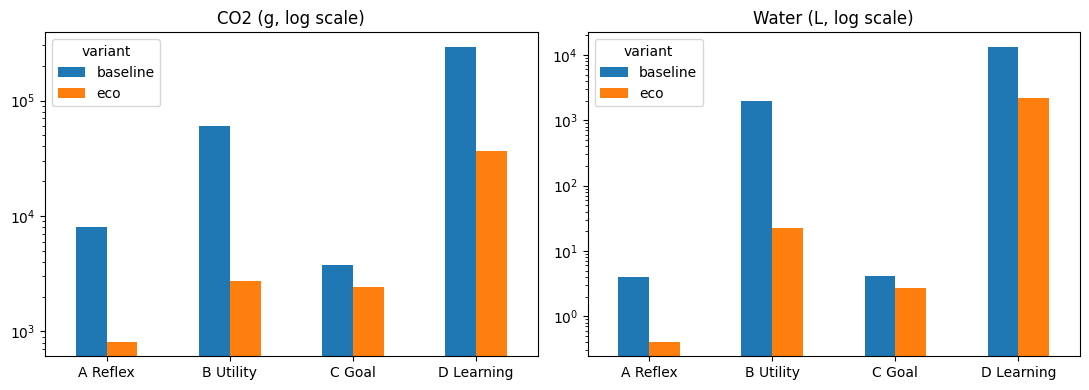

agent
A Reflex      89.8 % CO2 saved
B Utility     95.4 % CO2 saved
C Goal        35.7 % CO2 saved
D Learning    87.4 % CO2 saved
dtype: object


In [6]:
df = pd.DataFrame(results)
print(df.to_string(index=False))

pivot = df.pivot(index="agent", columns="variant", values=["co2_g", "water_l"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pivot["co2_g"][["baseline", "eco"]].plot.bar(ax=axes[0], logy=True, title="CO2 (g, log scale)")
pivot["water_l"][["baseline", "eco"]].plot.bar(ax=axes[1], logy=True, title="Water (L, log scale)")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

saving = (1 - pivot["co2_g"]["eco"] / pivot["co2_g"]["baseline"]) * 100
print(saving.round(1).astype(str) + " % CO2 saved")

## Conclusion

Each eco agent keeps the task goal and lowers the footprint through a different mechanism:
- **A (reflex):** sleeps until a rule fires, so it catches the same alerts with far less energy.
- **B (utility):** the footprint is a term inside the utility function.
- **C (goal-based):** safe routes are a constraint and planning gives the shortest path.
- **D (learning):** footprint is a term inside the reward, so the agent learns green habits.

**Limitation:** all cost values are assumed. Real deployments would replace them with measured figures.